# Prueba práctica — Python, pandas y visualización aplicada a Finanzas

## Magíster en Finanzas

### Duración sugerida
3 horas

### Modalidad
Individual, desarrollada en clases.

### Recursos permitidos
Puede utilizar apuntes, notebooks del curso, documentación, internet y herramientas de IA.

:::{important}
El uso de herramientas de apoyo no reemplaza la comprensión. En esta prueba se evaluará especialmente la capacidad de revisar datos, detectar errores, justificar decisiones y explicar resultados.
:::

---

## Objetivo general

El objetivo de esta actividad es integrar los contenidos básicos del curso mediante un caso aplicado a datos financieros y comerciales.

Durante la prueba deberá:

- leer datos desde un archivo CSV;
- explorar una base de datos con problemas reales de formato;
- limpiar datos corruptos;
- normalizar nombres escritos de distintas formas;
- transformar números que usan coma o punto decimal;
- crear funciones propias y aplicarlas con `pandas.apply`;
- generar nuevas columnas;
- filtrar información;
- agrupar datos;
- crear gráficos;
- interpretar resultados de manera breve.

:::{note}
El énfasis no está en hacer código perfecto, sino en mostrar un procedimiento razonable, ordenado y comprensible.
:::


# Contexto del caso

Una institución financiera está revisando el comportamiento de ventas de distintos ejecutivos durante un período corto.

La base contiene información de:

- fecha de venta;
- ejecutivo;
- región;
- producto financiero;
- monto vendido;
- comisión;
- número de clientes contactados;
- estado de la operación.

Sin embargo, la base fue construida manualmente y presenta varios problemas:

- nombres de ejecutivos escritos de manera inconsistente;
- regiones con espacios adicionales o diferencias de escritura;
- números con coma decimal y punto decimal mezclados;
- valores faltantes;
- valores imposibles o sospechosos;
- textos donde deberían existir números;
- operaciones rechazadas o pendientes.

La tarea consiste en limpiar parcialmente esta información y realizar un análisis exploratorio básico.

# Parte 0 — Generación del archivo de trabajo

Ejecute la siguiente celda para crear el archivo CSV que se usará en la prueba.

El archivo se llamará:

```python
ventas_magister_finanzas_corrupto.csv
```

:::{warning}
No modifique manualmente el archivo CSV. Toda corrección debe realizarse usando Python y pandas.
:::

In [446]:
csv_data = '''fecha,ejecutivo,region,producto,monto_venta,comision_pct,clientes_contactados,estado
2026-04-01,Ana Pérez,Norte,Fondo Mutuo,1250000,"1,5",12,Aprobada
2026-04-01,Ana Perez,Norte ,Fondo Mutuo,"1.300.000","1,5",14,Aprobada
2026-04-02,ANa  Pérez,norte,Seguro Vida,"980000","1.2",10,Aprobada
2026-04-02,Carlos Soto,Sur,Credito Consumo,"2.100.000","2,0",18,Aprobada
2026-04-03,Carlos  Soto,Sur ,Crédito Consumo,"2100000","2.0",veinte,Aprobada
2026-04-03,Carlo Soto,Sur,Credito Consumo,ERROR,"2,0",19,Rechazada
2026-04-04,María López,Centro,APV,"750000","1,8",9,Aprobada
2026-04-04,Maria Lopez, centro ,APV,"760.500","1.8",8,Aprobada
2026-04-05,Maria  López,Centro,APV,,"1,8",11,Pendiente
2026-04-05,Juan Torres,Metropolitana,Deposito Plazo,"1500000","0,9",16,Aprobada
2026-04-06,Juan  Torres,metropolitana,Depósito Plazo,"1.550.000","0.9",15,Aprobada
2026-04-06,J. Torres,Metropolitana,Deposito Plazo,"-100000","0,9",17,Aprobada
2026-04-07,Ana Pérez,Norte,Fondo Mutuo,"1.450.000","1,5",13,Aprobada
2026-04-07,Carlos Soto,Sur,Seguro Vida,"890000","1,2",12,Aprobada
2026-04-08,María López,Centro,APV,"820000","1,8",10,Aprobada
2026-04-08,Juan Torres,Metropolitana,Credito Hipotecario,"5.500.000","2,5",6,Aprobada
2026-04-09,Ana Perez,Norte,Seguro Vida,"1,050,000","1.2",11,Aprobada
2026-04-09,Carlos Soto,Sur,Credito Consumo,"2200000","dos",21,Aprobada
2026-04-10,Maria Lopez,Centro,APV,"830000","1,8",-3,Aprobada
2026-04-10,Juan Torres,Metropolitana,Deposito Plazo,"1600000","0,9",18,aprobada
2026-04-11,Ana Pérez,Norte,Fondo Mutuo,"1475000","1,5",13,Aprobada
2026-04-11,Carlos Soto,Sur,Credito Consumo,"2250000","2,0",22,Aprobada
2026-04-12,María López,Centro,APV,"840000","1,8",12,Aprobada
2026-04-12,Juan Torres,Metropolitana,Deposito Plazo,"1650000","0,9",19,Aprobada
'''

with open("ventas_magister_finanzas_corrupto.csv", "w", encoding="utf-8") as archivo:
    archivo.write(csv_data)

print("Archivo ventas_magister_finanzas_corrupto.csv creado correctamente.")

Archivo ventas_magister_finanzas_corrupto.csv creado correctamente.


# Parte 1 — Lectura de datos y primera inspección (15 puntos)

## Pregunta 1.1

Lea el archivo usando `pandas` con `pd.read_csv(...)`. Guarde el resultado en una variable llamada `df` y muestre las primeras filas.

:::{tip}
Recuerde importar pandas antes de leer el archivo.
:::

In [447]:
# Respuesta Pregunta 1.1

import pandas as pd

df = pd.read_csv("ventas_magister_finanzas_corrupto.csv")
print(df)

# Primero importo librería pandas para posteriormente leer el archivo csv y cargarlo en un DataFrame llamado df.

         fecha     ejecutivo         region             producto monto_venta  \
0   2026-04-01     Ana Pérez          Norte          Fondo Mutuo     1250000   
1   2026-04-01     Ana Perez         Norte           Fondo Mutuo   1.300.000   
2   2026-04-02    ANa  Pérez          norte          Seguro Vida      980000   
3   2026-04-02   Carlos Soto            Sur      Credito Consumo   2.100.000   
4   2026-04-03  Carlos  Soto           Sur       Crédito Consumo     2100000   
5   2026-04-03    Carlo Soto            Sur      Credito Consumo       ERROR   
6   2026-04-04   María López         Centro                  APV      750000   
7   2026-04-04   Maria Lopez        centro                   APV     760.500   
8   2026-04-05  Maria  López         Centro                  APV         NaN   
9   2026-04-05   Juan Torres  Metropolitana       Deposito Plazo     1500000   
10  2026-04-06  Juan  Torres  metropolitana       Depósito Plazo   1.550.000   
11  2026-04-06     J. Torres  Metropolit

In [448]:
# Con comando .head() muestro las primeras 3 filas del DataFrame.
df.head(3)

,fecha,ejecutivo,region,producto,monto_venta,comision_pct,clientes_contactados,estado
0,2026-04-01,Ana Pérez,Norte,Fondo Mutuo,1250000,"1,5",12,Aprobada
1,2026-04-01,Ana Perez,Norte,Fondo Mutuo,1.300.000,"1,5",14,Aprobada
2,2026-04-02,ANa Pérez,norte,Seguro Vida,980000,1.2,10,Aprobada


## Pregunta 1.2

Muestre información general de la base:

- cantidad de filas y columnas;
- nombres de columnas;
- tipos de datos;
- cantidad de valores faltantes por columna.

:::{note}
Esta pregunta busca que observe el estado original de los datos, antes de limpiarlos.
:::

In [449]:
# Respuesta Pregunta 1.2

df.info()
# Nos indica que el DataFrame tiene 8 columnas y 24 files, los tipos de datos son str (string) y no hay valores nulos.

<class 'pandas.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   fecha                 24 non-null     str  
 1   ejecutivo             24 non-null     str  
 2   region                24 non-null     str  
 3   producto              24 non-null     str  
 4   monto_venta           23 non-null     str  
 5   comision_pct          24 non-null     str  
 6   clientes_contactados  24 non-null     str  
 7   estado                24 non-null     str  
dtypes: str(8)
memory usage: 1.6 KB


In [450]:
df.columns
# Me muestra los nombres de las columnas del DataFrame.

Index(['fecha', 'ejecutivo', 'region', 'producto', 'monto_venta',
       'comision_pct', 'clientes_contactados', 'estado'],
      dtype='str')

In [451]:
# En este paso cargaré otras librerías necesarias.
import matplotlib.pyplot as plt
import numpy as np

## Pregunta 1.3

En algunas situaciones, los datos pueden leerse desde una URL. Escriba un ejemplo de cómo leería un archivo CSV desde una URL usando `pd.read_csv`.

No es necesario que la URL funcione. Lo importante es mostrar la estructura del código.

In [452]:
# Respuesta Pregunta 1.3
import pandas as pd
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"

url = pd.read_csv(url)

# Parte 2 — Diagnóstico de problemas en los datos (20 puntos)

## Pregunta 2.1

Revise los valores únicos de las columnas `ejecutivo`, `region`, `producto` y `estado`.

In [453]:
# Respuesta Pregunta 2.1
df[['ejecutivo', 'region', 'producto', 'estado']]

,ejecutivo,region,producto,estado
0,Ana Pérez,Norte,Fondo Mutuo,Aprobada
1,Ana Perez,Norte,Fondo Mutuo,Aprobada
2,ANa Pérez,norte,Seguro Vida,Aprobada
3,Carlos Soto,Sur,Credito Consumo,Aprobada
4,Carlos Soto,Sur,Crédito Consumo,Aprobada
5,Carlo Soto,Sur,Credito Consumo,Rechazada
6,María López,Centro,APV,Aprobada
7,Maria Lopez,centro,APV,Aprobada
8,Maria López,Centro,APV,Pendiente
9,Juan Torres,Metropolitana,Deposito Plazo,Aprobada


## Pregunta 2.2

Explique al menos **seis problemas** encontrados en la base de datos.

Debe mencionar problemas asociados a nombres escritos de forma distinta, espacios adicionales, mayúsculas/minúsculas, números con formato incorrecto, datos faltantes y valores sospechosos o imposibles.

:::{important}
Esta pregunta es clave. No basta con decir “hay errores”. Debe indicar dónde están y por qué son problemas.
:::

### Respuesta Pregunta 2.2

Escriba aquí su diagnóstico.

In [454]:
df

,fecha,ejecutivo,region,producto,monto_venta,comision_pct,clientes_contactados,estado
0,2026-04-01,Ana Pérez,Norte,Fondo Mutuo,1250000,"1,5",12,Aprobada
1,2026-04-01,Ana Perez,Norte,Fondo Mutuo,1.300.000,"1,5",14,Aprobada
2,2026-04-02,ANa Pérez,norte,Seguro Vida,980000,1.2,10,Aprobada
3,2026-04-02,Carlos Soto,Sur,Credito Consumo,2.100.000,"2,0",18,Aprobada
4,2026-04-03,Carlos Soto,Sur,Crédito Consumo,2100000,2.0,veinte,Aprobada
5,2026-04-03,Carlo Soto,Sur,Credito Consumo,ERROR,"2,0",19,Rechazada
6,2026-04-04,María López,Centro,APV,750000,"1,8",9,Aprobada
7,2026-04-04,Maria Lopez,centro,APV,760.500,1.8,8,Aprobada
8,2026-04-05,Maria López,Centro,APV,NaN,"1,8",11,Pendiente
9,2026-04-05,Juan Torres,Metropolitana,Deposito Plazo,1500000,"0,9",16,Aprobada


In [455]:
# Hay mismos nombres escritos con y sin tildes, lo que hace que Python los considere como personas diferentes.
# Hay espacios adicionales en un mismo nombre, lo que también hace que Python los considere como diferentes.
# Hay montos númericos como strings, lo que provoca que no puedan realizarse operaciones matémáticas. Al menos lo hace complejo.
# Las fechas también están como strings, lo que dificulta manejar. Este deben convertirse a formato fecha (datetime)
# Hay uso de mayúsculas y minúsculas de forma inconsistente, lo que hace que Python los considere como diferentes.
# Las comisiones tiene comas en vez de puntos, lo que hace que no se reconozcan como decimales.
# En la columna clientes: hay valores numéricos escritos como texto (veinte), lo que dificulta realizar operaciones matemáticas.

# Parte 3 — Limpieza de texto: nombres y categorías (20 puntos)

## Pregunta 3.1

Limpie la columna `region`. Debe crear una nueva columna llamada `region_limpia` que corrija espacios, mayúsculas/minúsculas y nombres equivalentes.

In [456]:
# Respuesta Pregunta 3.1
df['region_limpia'] = df['region'].str.strip().str.title()
df['region'] = region_limpia

df['region'].unique()

<StringArray>
['Norte', 'Sur', 'Centro', 'Metropolitana']
Length: 4, dtype: str

In [457]:
df['region_limpia']

0             Norte
1             Norte
2             Norte
3               Sur
4               Sur
5               Sur
6            Centro
7            Centro
8            Centro
9     Metropolitana
10    Metropolitana
11    Metropolitana
12            Norte
13              Sur
14           Centro
15    Metropolitana
16            Norte
17              Sur
18           Centro
19    Metropolitana
20            Norte
21              Sur
22           Centro
23    Metropolitana
Name: region_limpia, dtype: str

## Pregunta 3.2

Limpie la columna `estado`. Debe crear una nueva columna llamada `estado_limpio`. Asegúrese de que valores como `aprobada` y `Aprobada` sean tratados como la misma categoría.

In [458]:
# Respuesta Pregunta 3.2
df['estado_limpio'] = df['estado'].str.strip().str.title()
df['estado'] = estado_limpio

In [459]:
estado_limpio.unique()  

<StringArray>
['Aprobada', 'Rechazada', 'Pendiente']
Length: 3, dtype: str

In [460]:
df['estado_limpio']

0      Aprobada
1      Aprobada
2      Aprobada
3      Aprobada
4      Aprobada
5     Rechazada
6      Aprobada
7      Aprobada
8     Pendiente
9      Aprobada
10     Aprobada
11     Aprobada
12     Aprobada
13     Aprobada
14     Aprobada
15     Aprobada
16     Aprobada
17     Aprobada
18     Aprobada
19     Aprobada
20     Aprobada
21     Aprobada
22     Aprobada
23     Aprobada
Name: estado_limpio, dtype: str

## Pregunta 3.3

Limpie la columna `ejecutivo`. Debe crear una nueva columna llamada `ejecutivo_limpio`.

Debe resolver, al menos, estos casos: `Ana Pérez`, `Ana Perez`, `ANa  Pérez`, `Carlos Soto`, `Carlos  Soto`, `Carlo Soto`, `María López`, `Maria Lopez`, `Maria  López`, `Juan Torres`, `Juan  Torres`, `J. Torres`.

:::{warning}
Este punto tiene un poco más de dificultad. Puede usar reemplazos manuales con diccionarios, funciones, o una combinación de limpieza de texto y reglas.
:::

In [461]:
# Respuesta Pregunta 3.3
df['ejecutivo_limpio'] = df['ejecutivo'].str.strip().str.title().replace('Ana Pérez', 'Ana Perez').replace('ANa  Pérez', 'Ana Perez').replace('Ana  Pérez', 'Ana Perez').replace('Carlo Soto', 'Carlos Soto').replace('Carlos  Soto', 'Carlos Soto').replace('Maria  López', 'Maria Lopez').replace('María López', 'Maria Lopez').replace('Juan  Torres', 'Juan Torres').replace('J. Torres', 'Juan Torres')

In [462]:
ejecutivo_limpio.unique()

<StringArray>
['Ana Perez', 'Carlos Soto', 'Maria Lopez', 'Juan Torres']
Length: 4, dtype: str

In [463]:
df['ejecutivo_limpio']

0       Ana Perez
1       Ana Perez
2       Ana Perez
3     Carlos Soto
4     Carlos Soto
5     Carlos Soto
6     Maria Lopez
7     Maria Lopez
8     Maria Lopez
9     Juan Torres
10    Juan Torres
11    Juan Torres
12      Ana Perez
13    Carlos Soto
14    Maria Lopez
15    Juan Torres
16      Ana Perez
17    Carlos Soto
18    Maria Lopez
19    Juan Torres
20      Ana Perez
21    Carlos Soto
22    Maria Lopez
23    Juan Torres
Name: ejecutivo_limpio, dtype: str

## Pregunta 3.4

Después de limpiar, muestre nuevamente los valores únicos de `region_limpia`, `estado_limpio` y `ejecutivo_limpio`. Comente si la limpieza redujo el número de categorías.

In [464]:
# Respuesta Pregunta 3.4
region_limpia.unique()

<StringArray>
['Norte', 'Sur', 'Centro', 'Metropolitana']
Length: 4, dtype: str

In [465]:
estado_limpio.unique()

<StringArray>
['Aprobada', 'Rechazada', 'Pendiente']
Length: 3, dtype: str

In [466]:
ejecutivo_limpio.unique()

<StringArray>
['Ana Perez', 'Carlos Soto', 'Maria Lopez', 'Juan Torres']
Length: 4, dtype: str

### Comentario Pregunta 3.4

Escriba aquí su comentario.

# Parte 4 — Limpieza de números corruptos (25 puntos)

En esta base hay números con distintos formatos: `1250000`, `1.300.000`, `760.500`, `1,050,000`, `ERROR` y valores vacíos. Además, la columna `comision_pct` mezcla valores como `1,5`, `1.5` y `dos`.

## Pregunta 4.1

Cree una función llamada `limpiar_monto(valor)`. La función debe recibir un valor y devolver un número. Debe intentar resolver números normales, números con puntos como separador de miles, números con coma como separador de miles, valores vacíos y texto no convertible.

Cuando no pueda convertir un valor, puede devolver `None`, `np.nan` o un valor equivalente.

:::{important}
Debe aplicar esta función usando `pandas.apply`.
:::

In [467]:
# Respuesta Pregunta 4.1

# Primeros revisamos nulos y vacíos, para luego convertir a formato numérico, y así poder realizar operaciones matemáticas.
def limpiar_monto(valor):

    # Revisar nulos o vacíos
    if pd.isna(valor) or str(valor).strip() == "":
        return np.nan

    # Convertir a string
    valor = str(valor).strip()

    # Eliminar separadores de miles
    valor = valor.replace(".", "")
    valor = valor.replace(",", "")

    # Intentar convertir
    try:
        return float(valor)

    except ValueError:
        return np.nan


    

## Pregunta 4.2

Use la función anterior para crear una nueva columna `monto_venta_limpio`. Luego revise tipo de dato, valores faltantes y estadísticas descriptivas.

In [468]:
# Respuesta Pregunta 4.2
df['monto_venta_limpio'] = df['monto_venta'].apply(limpiar_monto)

In [469]:
df['monto_venta_limpio']

0     1250000.0
1     1300000.0
2      980000.0
3     2100000.0
4     2100000.0
5           NaN
6      750000.0
7      760500.0
8           NaN
9     1500000.0
10    1550000.0
11    -100000.0
12    1450000.0
13     890000.0
14     820000.0
15    5500000.0
16    1050000.0
17    2200000.0
18     830000.0
19    1600000.0
20    1475000.0
21    2250000.0
22     840000.0
23    1650000.0
Name: monto_venta_limpio, dtype: float64

## Pregunta 4.3

Cree una función llamada `limpiar_comision(valor)` que transforme `1,5` en `1.5`, `1.5` en `1.5`, y `dos` en valor faltante. Luego cree `comision_pct_limpia` usando `.apply(...)`.

In [470]:
# Respuesta Pregunta 4.3
def limpiar_comision(valor):
    # Revisar nulos o vacíos
    if pd.isna(valor) or str(valor).strip() == "":
        return np.nan

    # Convertir a string
    valor = str(valor).strip()

    # Reemplazar comas por puntos
    valor = valor.replace(",", ".")

    # Reemplazar palabras por números
    valor = valor.replace("dos", "2")

    # Intentar convertir
    try:
        return float(valor)

    except ValueError:
        return np.nan


In [471]:
df['comision_pct_limpia'] = df['comision_pct'].apply(limpiar_comision)
df['comision_pct_limpia']

0     1.5
1     1.5
2     1.2
3     2.0
4     2.0
5     2.0
6     1.8
7     1.8
8     1.8
9     0.9
10    0.9
11    0.9
12    1.5
13    1.2
14    1.8
15    2.5
16    1.2
17    2.0
18    1.8
19    0.9
20    1.5
21    2.0
22    1.8
23    0.9
Name: comision_pct_limpia, dtype: float64

## Pregunta 4.4

Limpie la columna `clientes_contactados`. Debe crear una nueva columna `clientes_contactados_limpio`. Considere que `veinte` no es un número y que un valor negativo de clientes no tiene sentido. Explique qué decisión tomó.

In [472]:
# Respuesta Pregunta 4.4
def clientes_contactados_limpios(valor):
    # Revisar nulos o vacíos
    if pd.isna(valor) or str(valor).strip() == "":
        return np.nan

    # Convertir a string
    valor = str(valor).strip()

    # Reemplazar palabras por números
    valor = valor.replace("veinte", "20")

    # Reemplazar números negativos por cero.
    valor = valor.replace("-3", "0")

    # Intentar convertir
    try:
        return int(valor)

    except ValueError:
        return np.nan

In [473]:
df['clientes_contactados_limpios'] = df['clientes_contactados'].apply(clientes_contactados_limpios)
df['clientes_contactados_limpios']

0     12
1     14
2     10
3     18
4     20
5     19
6      9
7      8
8     11
9     16
10    15
11    17
12    13
13    12
14    10
15     6
16    11
17    21
18     0
19    18
20    13
21    22
22    12
23    19
Name: clientes_contactados_limpios, dtype: int64

### Justificación Pregunta 4.4

Escriba aquí su justificación.

In [474]:
# Con Strip() se eliman espacios adicionales, números negativos los reemplazo por cero ya que decir que se contactaron -100 clientes es lo mismo que decir que no se contacto ninguno. 
# Los datos se convierten a número enteros y los str también a números.

# Parte 5 — Decisiones de limpieza final (20 puntos)

## Pregunta 5.1

Cree un nuevo DataFrame llamado `df_limpio` con solamente las filas que usted considere válidas para el análisis. Como mínimo, revise montos faltantes, comisiones faltantes, clientes faltantes, montos negativos, clientes negativos y operaciones rechazadas o pendientes.

:::{warning}
No hay una única respuesta correcta. Debe explicar claramente qué decidió eliminar, corregir o conservar.
:::

In [475]:
# Respuesta Pregunta 5.1
df_limpio = df[['fecha', 'ejecutivo_limpio', 'region_limpia', 'producto', 'monto_venta_limpio', 'comision_pct_limpia', 'clientes_contactados_limpios', 'estado_limpio']]
df_limpio

,fecha,ejecutivo_limpio,region_limpia,producto,monto_venta_limpio,comision_pct_limpia,clientes_contactados_limpios,estado_limpio
0,2026-04-01,Ana Perez,Norte,Fondo Mutuo,1250000.0,1.5,12,Aprobada
1,2026-04-01,Ana Perez,Norte,Fondo Mutuo,1300000.0,1.5,14,Aprobada
2,2026-04-02,Ana Perez,Norte,Seguro Vida,980000.0,1.2,10,Aprobada
3,2026-04-02,Carlos Soto,Sur,Credito Consumo,2100000.0,2.0,18,Aprobada
4,2026-04-03,Carlos Soto,Sur,Crédito Consumo,2100000.0,2.0,20,Aprobada
5,2026-04-03,Carlos Soto,Sur,Credito Consumo,NaN,2.0,19,Rechazada
6,2026-04-04,Maria Lopez,Centro,APV,750000.0,1.8,9,Aprobada
7,2026-04-04,Maria Lopez,Centro,APV,760500.0,1.8,8,Aprobada
8,2026-04-05,Maria Lopez,Centro,APV,NaN,1.8,11,Pendiente
9,2026-04-05,Juan Torres,Metropolitana,Deposito Plazo,1500000.0,0.9,16,Aprobada


In [476]:
df_limpio2 = df_limpio.drop([5, 8, 11])

In [477]:
df_limpio2

,fecha,ejecutivo_limpio,region_limpia,producto,monto_venta_limpio,comision_pct_limpia,clientes_contactados_limpios,estado_limpio
0,2026-04-01,Ana Perez,Norte,Fondo Mutuo,1250000.0,1.5,12,Aprobada
1,2026-04-01,Ana Perez,Norte,Fondo Mutuo,1300000.0,1.5,14,Aprobada
2,2026-04-02,Ana Perez,Norte,Seguro Vida,980000.0,1.2,10,Aprobada
3,2026-04-02,Carlos Soto,Sur,Credito Consumo,2100000.0,2.0,18,Aprobada
4,2026-04-03,Carlos Soto,Sur,Crédito Consumo,2100000.0,2.0,20,Aprobada
6,2026-04-04,Maria Lopez,Centro,APV,750000.0,1.8,9,Aprobada
7,2026-04-04,Maria Lopez,Centro,APV,760500.0,1.8,8,Aprobada
9,2026-04-05,Juan Torres,Metropolitana,Deposito Plazo,1500000.0,0.9,16,Aprobada
10,2026-04-06,Juan Torres,Metropolitana,Depósito Plazo,1550000.0,0.9,15,Aprobada
12,2026-04-07,Ana Perez,Norte,Fondo Mutuo,1450000.0,1.5,13,Aprobada


## Pregunta 5.2

Explique brevemente sus criterios de limpieza final.

### Respuesta Pregunta 5.2

In [478]:
# Quite datos incoherentes, como el monto de venta negativo, el número de clientes contactados negativo, y el monto de venta con error. Estos datos no aportan información útil y pueden distorsionar los análisis posteriores.

# Parte 6 — Creación de nuevas variables financieras (20 puntos)

## Pregunta 6.1

Cree una columna llamada `comision_monto` calculada como `monto_venta_limpio * comision_pct_limpia / 100`.

In [479]:
# Respuesta Pregunta 6.1
df_limpio2['comision_monto'] = df_limpio2['monto_venta_limpio'] * df_limpio2['comision_pct_limpia'] / 100
df_limpio2['comision_monto']

0      18750.0
1      19500.0
2      11760.0
3      42000.0
4      42000.0
6      13500.0
7      13689.0
9      13500.0
10     13950.0
12     21750.0
13     10680.0
14     14760.0
15    137500.0
16     12600.0
17     44000.0
18     14940.0
19     14400.0
20     22125.0
21     45000.0
22     15120.0
23     14850.0
Name: comision_monto, dtype: float64

## Pregunta 6.2

Cree una función llamada `clasificar_monto(monto)`. La función debe clasificar cada venta en `Baja` si el monto es menor a 1.000.000, `Media` si está entre 1.000.000 y 2.000.000, y `Alta` si es mayor a 2.000.000. Luego cree `categoria_monto` usando `.apply(...)`.

In [480]:
# Respuesta Pregunta 6.2
def clasificar_monto(monto):
    if monto < 1000000:
        return "Bajo"
    elif 1000000 <= monto < 2000000:
        return "Medio"
    else:
        return "Alto"
    
categoria_monto = df_limpio2['monto_venta_limpio'].apply(clasificar_monto)
df_limpio2['categoria_monto']

KeyError: 'categoria_monto'

## Pregunta 6.3

Calcule una columna llamada `monto_por_cliente`, definida como `monto_venta_limpio / clientes_contactados_limpio`. Luego describa brevemente qué podría representar esta variable.

In [ ]:
# Respuesta Pregunta 6.3
monto_por_cliente = df_limpio2['monto_venta_limpio'] / df_limpio2['clientes_contactados_limpios']
df_limpio2['monto_por_cliente'] = monto_por_cliente
df_limpio2['monto_por_cliente']


0     1.041667e+05
1     9.285714e+04
2     9.800000e+04
3     1.166667e+05
4     1.050000e+05
6     8.333333e+04
7     9.506250e+04
9     9.375000e+04
10    1.033333e+05
12    1.115385e+05
13    7.416667e+04
14    8.200000e+04
15    9.166667e+05
16    9.545455e+04
17    1.047619e+05
18             inf
19    8.888889e+04
20    1.134615e+05
21    1.022727e+05
22    7.000000e+04
23    8.684211e+04
Name: monto_por_cliente, dtype: float64

### Interpretación Pregunta 6.3

# Parte 7 — Análisis exploratorio con pandas (25 puntos)

## Pregunta 7.1

Calcule monto total vendido, comisión total estimada, venta promedio, número total de operaciones válidas y promedio de clientes contactados.

In [ ]:
# Respuesta Pregunta 7.1
df_limpio2.info()

<class 'pandas.DataFrame'>
Index: 21 entries, 0 to 23
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   fecha                         21 non-null     str    
 1   ejecutivo_limpio              21 non-null     str    
 2   region_limpia                 21 non-null     str    
 3   producto                      21 non-null     str    
 4   monto_venta_limpio            21 non-null     float64
 5   comision_pct_limpia           21 non-null     float64
 6   clientes_contactados_limpios  21 non-null     int64  
 7   estado_limpio                 21 non-null     str    
 8   comision_monto                21 non-null     float64
 9   categoria_monto               21 non-null     str    
 10  monto_por_cliente             21 non-null     float64
dtypes: float64(4), int64(1), str(6)
memory usage: 2.0 KB


In [481]:
monto_total_ventas = df_limpio2['monto_venta_limpio'].sum()
print('monto_total_ventas:', monto_total_ventas)

monto_total_ventas: 32845500.0


In [ ]:
monto_total_comisiones = df_limpio2['comision_monto'].sum()
print('monto_total_comisiones:', monto_total_comisiones)

monto_total_comisiones: 556374.0


In [ ]:
venta_promedio = df_limpio2['monto_venta_limpio'].mean()
print('venta_promedio:', venta_promedio)

venta_promedio: 1564071.4285714286


In [ ]:
promedio_clientes_contactados = df_limpio2['clientes_contactados_limpios'].mean()
print('promedio_clientes_contactados:', promedio_clientes_contactados)

promedio_clientes_contactados: 13.285714285714286


## Pregunta 7.2

Agrupe por `ejecutivo_limpio` y calcule monto total vendido, comisión total, número de operaciones y promedio de monto por cliente. Ordene el resultado de mayor a menor monto vendido.

In [ ]:
df_limpio2.groupby(ejecutivo_limpio)['monto_venta_limpio'].sum()

ejecutivo
Ana Perez       7505000.0
Carlos Soto     9540000.0
Juan Torres    11800000.0
Maria Lopez     4000500.0
Name: monto_venta_limpio, dtype: float64

In [ ]:
df_limpio2.groupby(ejecutivo_limpio)['comision_monto'].sum()

ejecutivo
Ana Perez      106485.0
Carlos Soto    183680.0
Juan Torres    194200.0
Maria Lopez     72009.0
Name: comision_monto, dtype: float64

In [ ]:
df_limpio2.groupby(ejecutivo_limpio)['comision_monto'].sum()

## Pregunta 7.3

Agrupe por `region_limpia` y calcule monto promedio, monto total y comisión total. Interprete brevemente.

In [ ]:
df_limpio2.groupby('region_limpia')['monto_por_cliente'].mean()

region_limpia
Centro                    inf
Metropolitana    2.578962e+05
Norte            1.025797e+05
Sur              1.005736e+05
Name: monto_por_cliente, dtype: float64

### Interpretación Pregunta 7.3

## Pregunta 7.4

Filtre y muestre ventas de categoría `Alta`, operaciones con comisión mayor al promedio y operaciones del ejecutivo que usted elija. Explique por qué eligió ese ejecutivo.

In [ ]:
# Respuesta Pregunta 7.4
df_limpio2.loc[df_limpio2['categoria_monto'] == 'Alto']

,fecha,ejecutivo_limpio,region_limpia,producto,monto_venta_limpio,comision_pct_limpia,clientes_contactados_limpios,estado_limpio,comision_monto,categoria_monto,monto_por_cliente
3,2026-04-02,Carlos Soto,Sur,Credito Consumo,2100000.0,2.0,18,Aprobada,42000.0,Alto,116666.666667
4,2026-04-03,Carlos Soto,Sur,Crédito Consumo,2100000.0,2.0,20,Aprobada,42000.0,Alto,105000.000000
15,2026-04-08,Juan Torres,Metropolitana,Credito Hipotecario,5500000.0,2.5,6,Aprobada,137500.0,Alto,916666.666667
17,2026-04-09,Carlos Soto,Sur,Credito Consumo,2200000.0,2.0,21,Aprobada,44000.0,Alto,104761.904762
21,2026-04-11,Carlos Soto,Sur,Credito Consumo,2250000.0,2.0,22,Aprobada,45000.0,Alto,102272.727273


In [ ]:
df_limpio2.describe()

c:\Users\aacar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,monto_venta_limpio,comision_pct_limpia,clientes_contactados_limpios,comision_monto,monto_por_cliente
count,2.100000e+01,21.000000,21.000000,21.000000,2.100000e+01
mean,1.564071e+06,1.557143,13.285714,26494.000000,inf
std,1.027818e+06,0.452296,5.367894,27932.272724,NaN
min,7.500000e+05,0.900000,0.000000,10680.000000,7.000000e+04
25%,8.900000e+05,1.200000,10.000000,13689.000000,8.888889e+04
50%,1.450000e+06,1.500000,13.000000,14940.000000,9.800000e+04
75%,1.650000e+06,1.800000,18.000000,22125.000000,1.050000e+05
max,5.500000e+06,2.500000,22.000000,137500.000000,inf


In [ ]:
# $ 26.494 es el promedio de comisión.
# Comisiones sobre el promedio.

df_limpio2.loc[df_limpio2['comision_monto'] > df_limpio2['comision_monto'].mean()]

,fecha,ejecutivo_limpio,region_limpia,producto,monto_venta_limpio,comision_pct_limpia,clientes_contactados_limpios,estado_limpio,comision_monto,categoria_monto,monto_por_cliente
3,2026-04-02,Carlos Soto,Sur,Credito Consumo,2100000.0,2.0,18,Aprobada,42000.0,Alto,116666.666667
4,2026-04-03,Carlos Soto,Sur,Crédito Consumo,2100000.0,2.0,20,Aprobada,42000.0,Alto,105000.000000
15,2026-04-08,Juan Torres,Metropolitana,Credito Hipotecario,5500000.0,2.5,6,Aprobada,137500.0,Alto,916666.666667
17,2026-04-09,Carlos Soto,Sur,Credito Consumo,2200000.0,2.0,21,Aprobada,44000.0,Alto,104761.904762
21,2026-04-11,Carlos Soto,Sur,Credito Consumo,2250000.0,2.0,22,Aprobada,45000.0,Alto,102272.727273


### Comentario Pregunta 7.4

# Parte 8 — Visualización de datos (25 puntos)

Use `matplotlib` para construir los gráficos solicitados. Los gráficos deben tener título, nombres de ejes y, cuando corresponda, leyenda.

## Pregunta 8.1

Construya un gráfico de barras con el monto total vendido por ejecutivo.

Text(0, 0.5, 'Monto Total de Ventas')

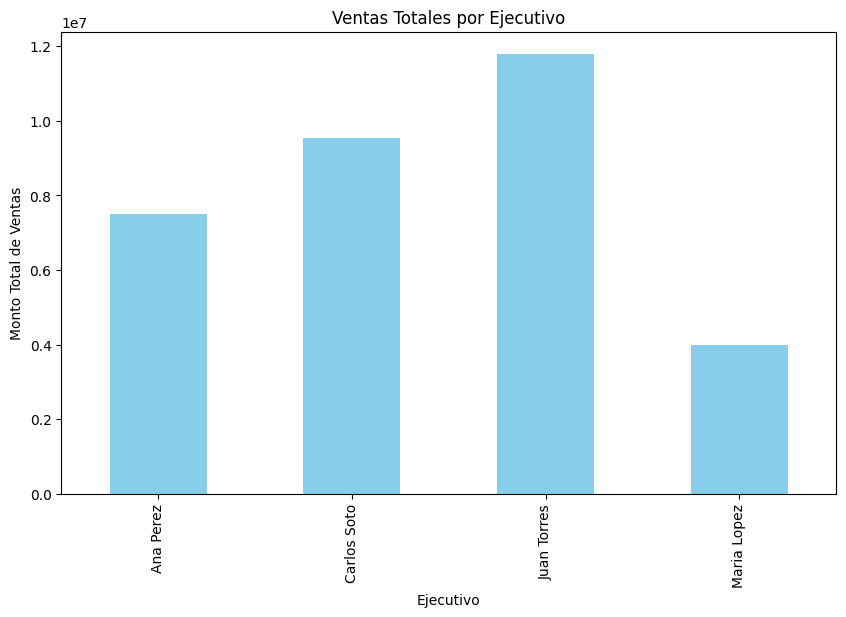

In [484]:
# Respuesta Pregunta 8.1
ventas_ejecutivo = df_limpio2.groupby('ejecutivo_limpio')['monto_venta_limpio'].sum()

plt.figure(figsize=(10, 6))
ventas_ejecutivo.plot(kind='bar', color='skyblue')
plt.title('Ventas Totales por Ejecutivo')
plt.xlabel('Ejecutivo')
plt.ylabel('Monto Total de Ventas')

## Pregunta 8.2

Construya un gráfico de barras con el monto total vendido por región.

Text(0, 0.5, 'Monto Total de Ventas')

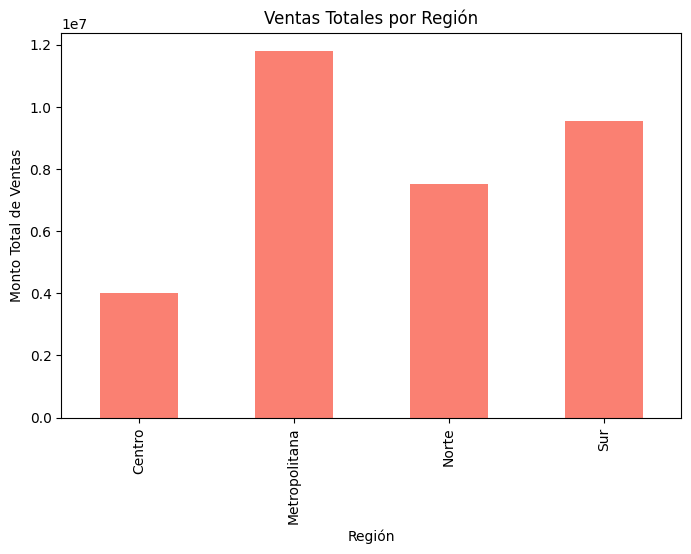

In [486]:
# Respuesta Pregunta 8.2

venta_por_region = df_limpio2.groupby('region_limpia')['monto_venta_limpio'].sum()

plt.figure(figsize=(8, 5))
venta_por_region.plot(kind='bar', color='salmon')
plt.title('Ventas Totales por Región')
plt.xlabel('Región')
plt.ylabel('Monto Total de Ventas')

## Pregunta 8.3

Construya un gráfico de línea que muestre la evolución diaria del monto vendido total. Para esto deberá agrupar por fecha.

In [ ]:
# Respuesta Pregunta 8.3

## Pregunta 8.4

Construya un gráfico de dispersión (`scatter`) entre clientes contactados y monto vendido. Comente brevemente si observa alguna relación visual.

In [494]:
print(df_limpio2.columns)

Index(['fecha', 'ejecutivo_limpio', 'region_limpia', 'producto',
       'monto_venta_limpio', 'comision_pct_limpia',
       'clientes_contactados_limpios', 'estado_limpio', 'comision_monto'],
      dtype='str')


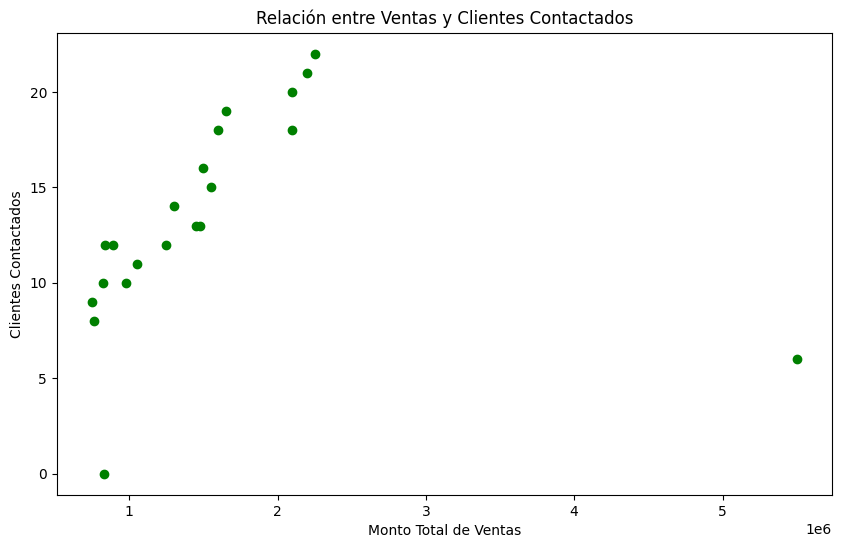

In [495]:
plt.figure(figsize=(10, 6))
plt.scatter(df_limpio2['monto_venta_limpio'], df_limpio2['clientes_contactados_limpios'], color='green')
plt.xlabel('Monto Total de Ventas')
plt.ylabel('Clientes Contactados')
plt.title('Relación entre Ventas y Clientes Contactados')
plt.show()


In [ ]:
# Se observa una correlación entre el aumento del monto de venta y el número de clientes contactados, lo que sugiere que a medida que se contactan más clientes, el monto total de ventas tiende a aumentar. Sin embargo, también se pueden observar algunos puntos atípicos, como ventas altas con pocos clientes contactados o ventas bajas con muchos clientes contactados, lo que indica que otros factores también pueden influir en el monto de las ventas.

### Interpretación Pregunta 8.4

# Parte 9 — Pregunta de integración y reflexión (10 puntos)

## Pregunta 9.1

Escriba una conclusión breve del análisis. Debe mencionar:

- qué ejecutivo o región tuvo mejor desempeño;
- qué problemas de datos afectaban más el análisis;
- por qué fue necesario limpiar antes de graficar o agrupar;
- una recomendación para mejorar el registro futuro de datos.

Extensión sugerida: entre 8 y 12 líneas.

### Respuesta Pregunta 9.1

In [ ]:
# Respuestas Pregunta 9.1
a) Juan Torres es el ejecutivo con mayores ventas totales. En cuanto a regiones, la metropolitana es la que tiene el mayor montos de ventas por cliente.
b) A mi parecer, las mayúsculas/minúsculas, espacios en adicionales y acentos.
c) Fue necesario limpiar los datos para poder realizar análisis precisos. Con errores los resultados terminan sesgados o incorrectos dado por ejemplo la duplicación de nombres con y sin tildes, o con espacios adicionales, lo que hace que Python los considere como diferentes personas. Además, los montos de venta y comisiones estaban como strings con formatos inconsistentes, lo que dificultaba realizar operaciones matemáticas. La limpieza de datos permitió estandarizar los nombres, convertir los montos a formato numérico y eliminar valores incoherentes, lo que resultó en análisis más precisos y confiables.
d) Una recomendación para mejorar la calidad de los datos en el futuro es implementar validaciones y formatos estandarizados al momento de ingresar los datos. Por ejemplo, se podrían utilizar menús desplegables para seleccionar ejecutivos, regiones y productos, lo que reduciría la posibilidad de errores tipográficos. Además, se podrían establecer formatos específicos para montos de venta y comisiones, asegurando que se ingresen como números con puntos decimales en lugar de comas o texto. También sería útil implementar controles para evitar valores negativos en clientes contactados y asegurar que las fechas se ingresen en un formato consistente. Estas medidas ayudarían a mantener la integridad de los datos y facilitarían análisis más precisos en el futuro.

# Pauta general de evaluación

| Sección | Puntaje |
|---|---:|
| Lectura e inspección inicial | 15 |
| Diagnóstico de problemas | 20 |
| Limpieza de texto | 20 |
| Limpieza de números corruptos | 25 |
| Decisiones de limpieza final | 20 |
| Nuevas variables financieras | 20 |
| Análisis exploratorio con pandas | 25 |
| Visualización de datos | 25 |
| Conclusión e interpretación | 10 |
| **Total** | **180** |

---

# Recomendaciones para desarrollar la prueba

:::{admonition} Recomendación
:class: tip
Trabaje paso a paso. No intente resolver todo de una vez. Primero lea los datos, luego observe, después limpie y recién al final analice.
:::

:::{warning}
Si un gráfico o agrupación entrega resultados extraños, revise si los datos fueron limpiados correctamente. Muchas veces el problema no está en el gráfico, sino en los datos de entrada.
:::

:::{important}
Debe dejar evidencia de su proceso. Las decisiones de limpieza deben quedar explicadas en texto, no solamente implementadas en código.
:::

# Entregas a correo jorge.vergara.q@usach.cl
Incluir en asunto Magister Finanzas: Tarea 1: Nombre usted